In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import optuna

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import lightgbm as lgb

ROOT = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / "data" / "processed"

X = pd.read_parquet(DATA_PROCESSED / "X.parquet")
Y = pd.read_parquet(DATA_PROCESSED / "Y.parquet")

metadata = pd.read_parquet(DATA_PROCESSED / "metadata_clean.parquet")



print(X.shape)
print(metadata.shape)



C:\Users\yzouarhi\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(549971, 110)
(549971, 391)


In [58]:
#construire un dataframe de stratification pour le split train/test
strat = pd.DataFrame(index=X.index)

strat["surface"] = X["in.geometry_floor_area"]
strat["vintage"] = X["in.vintage"]
strat["occupants"] = X["in.occupants"]

strat["heating"] = metadata["in.heating_fuel"].astype(str)


In [59]:
#faire des categories pour les variables continues pour la stratification
strat["surface_cat"] = pd.qcut(
    strat["surface"],
    q=4,
    labels=False,
    duplicates="drop"
)

strat["vintage_cat"] = pd.qcut(
    strat["vintage"],
    q=4,
    labels=False,
    duplicates="drop"
)

strat["occupants_cat"] = pd.qcut(
    strat["occupants"],
    q=3,
    labels=False,
    duplicates="drop"
)



In [60]:

heating_map = {
    "Natural Gas": "Gas",
    "Electricity": "Electric",
    "Fuel Oil": "Oil",
    "Propane": "Oil",
    "Wood": "Other",
    "None": "Other",
    "Other Fuel": "Other"
}

strat["heating_clean"] = strat["heating"].map(heating_map)


In [61]:
print(strat["heating"].value_counts())


heating
Natural Gas    262274
Electricity    222954
Fuel Oil        25751
Propane         24446
Wood             8603
None             4051
Other Fuel       1892
Name: count, dtype: int64


In [62]:

strat["stratum"] = (
    strat["surface_cat"].astype(str)
    + "_"
    + strat["vintage_cat"].astype(str)
    + "_"
    + strat["occupants_cat"].astype(str)
    + "_"
    + strat["heating"]
)



In [63]:

group_sizes = strat["stratum"].value_counts()

print(group_sizes.describe())

count      336.000000
mean      1636.818452
std       2772.948449
min          4.000000
25%         83.500000
50%        327.000000
75%       1579.000000
max      18223.000000
Name: count, dtype: float64


Nombre total de groupes : 336
Groupes avec moins de 2 observations : 0
Groupes avec moins de 5 observations : 1
Groupes avec moins de 10 observations : 4
Groupes avec moins de 20 observations : 11


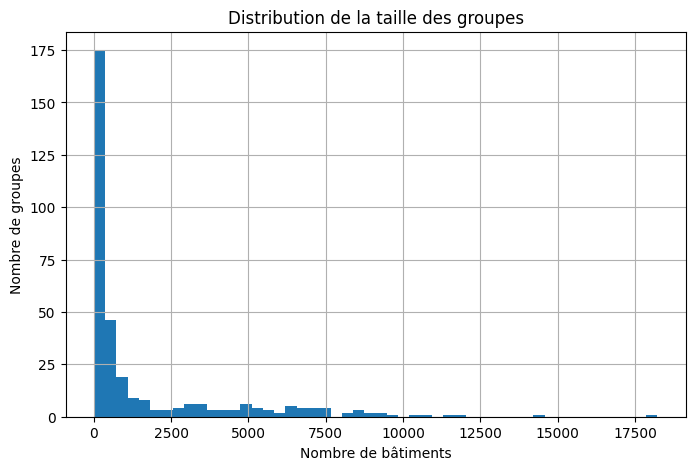

In [64]:
print("Nombre total de groupes :", len(group_sizes))

print("Groupes avec moins de 2 observations :",
      (group_sizes < 2).sum())

print("Groupes avec moins de 5 observations :",
      (group_sizes < 5).sum())

print("Groupes avec moins de 10 observations :",
      (group_sizes < 10).sum())

print("Groupes avec moins de 20 observations :",
      (group_sizes < 20).sum())

plt.figure(figsize=(8,5))

group_sizes.hist(bins=50)

plt.xlabel("Nombre de bâtiments")
plt.ylabel("Nombre de groupes")
plt.title("Distribution de la taille des groupes")

plt.show()



In [65]:
# fussion des groupes rares en un seul groupe "RARE"
counts = strat["stratum"].value_counts()
rare_groups = counts[counts < 10].index

strat["stratum"] = strat["stratum"].replace(rare_groups, "RARE")


In [66]:
idx = np.arange(len(X))

idx_train, idx_test = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=strat["stratum"]
)



print(strat.iloc[idx_train]["stratum"].value_counts(normalize=True).head())
print(strat.iloc[idx_test]["stratum"].value_counts(normalize=True).head())

stratum
0_1_0_Electricity    0.033134
0_0_0_Electricity    0.026004
2_0_2_Natural Gas    0.021706
3_0_2_Natural Gas    0.021088
2_0_2_Electricity    0.019317
Name: proportion, dtype: float64
stratum
0_1_0_Electricity    0.033138
0_0_0_Electricity    0.026001
2_0_2_Natural Gas    0.021710
3_0_2_Natural Gas    0.021092
2_0_2_Electricity    0.019319
Name: proportion, dtype: float64


In [67]:
print("Nombre de groupes :", strat["stratum"].nunique())
print(strat["stratum"].value_counts().describe())


Nombre de groupes : 333
count      333.000000
mean      1651.564565
std       2781.060620
min         12.000000
25%         86.000000
50%        332.000000
75%       1609.000000
max      18223.000000
Name: count, dtype: float64


In [68]:
X_train_final, X_test = train_test_split(
    X,
    test_size=0.2,
    stratify=strat["stratum"],
    random_state=42
)

Y_train_final = Y.loc[X_train_final.index]
Y_test  = Y.loc[X_test.index]



In [69]:
# Split the training set into training and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_final,
    Y_train_final,
    test_size=0.2,
    random_state=42
)



In [70]:
results_dummy = {}

for target in Y.columns:

    median = Y_train[target].median()
    y_pred = np.full(len(Y_test), median)

    results_dummy[target] = {
        "RMSE": np.sqrt(mean_squared_error(Y_test[target], y_pred)),
        "MAE": mean_absolute_error(Y_test[target], y_pred),
        "R2": r2_score(Y_test[target], y_pred)
    }

pd.DataFrame(results_dummy).T


,RMSE,MAE,R2
out.electricity.total.energy_consumption..kwh,8851.434490,5976.310358,-0.056077
out.natural_gas.total.energy_consumption..kwh,18245.998693,10362.439949,-0.255198
out.fuel_oil.total.energy_consumption..kwh,7168.887836,1277.618526,-0.032803
out.propane.total.energy_consumption..kwh,6313.329287,1111.424763,-0.031983
out.emissions.total.lrmer_mid_case_25..co2e_kg,4644.262700,3258.194809,-0.072657


In [71]:
models = {}
predictions = {}
results = {}

for target in Y.columns:

    print(f"\n========== {target} ==========")

    model = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1,
        reg_lambda=5,
        random_state=42
    )

    model.fit(
        X_train,
        Y_train[target],
        eval_set=[(X_val, Y_val[target])],
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    models[target] = model

    y_pred = model.predict(X_test)
    predictions[target] = y_pred

    results[target] = {
        "RMSE": np.sqrt(mean_squared_error(Y_test[target], y_pred)),
        "MAE": mean_absolute_error(Y_test[target], y_pred),
        "R2": r2_score(Y_test[target], y_pred)
    }



========== out.electricity.total.energy_consumption..kwh ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,015949 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 351980, number of used features: 110
[LightGBM] [Info] Start training from score 11758,366880

========== out.natural_gas.total.energy_consumption..kwh ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,017518 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 351980, number of used features: 110
[LightGBM] [Info] Start training from score 10581,448888

========== out.fuel_oil.total.energy_

In [72]:
df_results = pd.DataFrame(results).T
df_results = df_results.sort_values("R2", ascending=False)
df_results


,RMSE,MAE,R2
out.emissions.total.lrmer_mid_case_25..co2e_kg,1310.898812,705.219993,0.914539
out.natural_gas.total.energy_consumption..kwh,5887.462486,2883.293894,0.869313
out.electricity.total.energy_consumption..kwh,3395.330398,1682.591967,0.844607
out.fuel_oil.total.energy_consumption..kwh,4137.524275,958.725678,0.655971
out.propane.total.energy_consumption..kwh,4285.127807,1124.939617,0.524574


In [73]:
results_pct = {}

for target in Y.columns:
    y_true = Y_test[target]
    y_pred = predictions[target]

    mean = y_true.mean()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    results_pct[target] = {
        "RMSE": rmse,
        "Erreur RMSE_%": rmse / mean * 100,
        "MAE": mae,
        "Erreur MAE_%": mae / mean * 100,
        "R2": r2_score(y_true, y_pred),
    }

results_df = (
    pd.DataFrame(results_pct)
    .T
    .sort_values("RMSE", ascending=True)
)
results_df

,RMSE,Erreur RMSE_%,MAE,Erreur MAE_%,R2
out.emissions.total.lrmer_mid_case_25..co2e_kg,1310.898812,24.145116,705.219993,12.989270,0.914539
out.electricity.total.energy_consumption..kwh,3395.330398,28.920254,1682.591967,14.331738,0.844607
out.fuel_oil.total.energy_consumption..kwh,4137.524275,323.846609,958.725678,75.040058,0.655971
out.propane.total.energy_consumption..kwh,4285.127807,385.552666,1124.939617,101.215994,0.524574
out.natural_gas.total.energy_consumption..kwh,5887.462486,55.505952,2883.293894,27.183184,0.869313


In [74]:
def objective(trial, X_train, y_train, X_val, y_val):

    params = {
        "n_estimators": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 150),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),

        "random_state": 42,
        "n_jobs": -1
    }

    model = lgb.LGBMRegressor(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    return rmse 


In [75]:
target = "out.electricity.total.energy_consumption..kwh"

study = optuna.create_study(direction="minimize")

study.optimize(
    lambda trial: objective(
        trial,
        X_train_final,
        Y_train_final[target],
        X_val,
        Y_val[target]
    ),
    n_trials=30
)

print("Best params:", study.best_params)
print("Best RMSE:", study.best_value)


[I 2026-07-06 16:22:43,241] A new study created in memory with name: no-name-b45324ad-847f-493d-b6e7-e039fe5e55b0


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,024228 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1370
[LightGBM] [Info] Number of data points in the train set: 439976, number of used features: 110
[LightGBM] [Info] Start training from score 11759,412164
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-07-06 16:22:55,620] Trial 0 finished with value: 3585.29505203577 and parameters: {'learning_rate': 0.04943502242988161, 'num_leaves': 119, 'max_depth': 4, 'min_child_samples': 144, 'subsample': 0.8113426794492493, 'colsample_bytree': 0.7722319384958204, 'reg_alpha': 0.3684246936839142, 'reg_lambda': 2.7854892954747514}. Best is trial 0 with value: 3585.29505203577.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,022969 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1370
[LightGBM] [Info] Number of data points in the train set: 439976, number of used features: 110
[LightGBM] [Info] Start training from score 11759,412164
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-07-06 16:23:06,366] Trial 1 finished with value: 3847.5228266928925 and parameters: {'learning_rate': 0.05357784983987401, 'num_leaves': 90, 'max_depth': 3, 'min_child_samples': 99, 'subsample': 0.6339539492075572, 'colsample_bytree': 0.9144543145807041, 'reg_alpha': 0.023764357916495893, 'reg_lambda': 0.06350496176860121}. Best is trial 0 with value: 3585.29505203577.


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,022490 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1370
[LightGBM] [Info] Number of data points in the train set: 439976, number of used features: 110
[LightGBM] [Info] Start training from score 11759,412164
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-07-06 16:32:57,976] Trial 28 finished with value: 1991.0636169221814 and parameters: {'learning_rate': 0.09431437288426749, 'num_leaves': 138, 'max_depth': 11, 'min_child_samples': 89, 'subsample': 0.6746519789911304, 'colsample_bytree': 0.6794704242817985, 'reg_alpha': 3.0355586040940628, 'reg_lambda': 8.236535900860202}. Best is trial 10 with value: 1806.974978631213.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,024318 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1370
[LightGBM] [Info] Number of data points in the train set: 439976, number of used features: 110
[LightGBM] [Info] Start training from score 11759,412164
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-07-06 16:33:21,775] Trial 29 finished with value: 2306.6444773776198 and parameters: {'learning_rate': 0.07406661289806993, 'num_leaves': 116, 'max_depth': 12, 'min_child_samples': 147, 'subsample': 0.7964114651418415, 'colsample_bytree': 0.7605547659356399, 'reg_alpha': 3.8149046445268757, 'reg_lambda': 9.262125326715877}. Best is trial 10 with value: 1806.974978631213.


Best params: {'learning_rate': 0.09699307314502215, 'num_leaves': 150, 'max_depth': 12, 'min_child_samples': 61, 'subsample': 0.7290212845982496, 'colsample_bytree': 0.7546209770407816, 'reg_alpha': 4.776900722887304, 'reg_lambda': 8.682914195278322}
Best RMSE: 1806.974978631213
